In [160]:
import pandas as pd
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import AdamW
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from tqdm import tqdm
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from scipy.signal import find_peaks

In [2]:
data_dir = Path('/home/andrze06/projects/Spectras-latent-space/data/multimodal_spectroscopic_dataset')
files = sorted(data_dir.glob("aligned_chunk_*.parquet"))
dfs = [pd.read_parquet(f, columns=['smiles', 'c_nmr_spectra']) for f in files]
df = pd.concat(dfs, ignore_index=True)

In [25]:
scale = 1e4

def transform_data(targets_list):
    return [np.log1p(t * scale).astype(np.float32) for t in tqdm(targets_list)]

def inverse_transform_data(y):
    return np.expm1(y) / scale

data = np.array(df['c_nmr_spectra'].to_list(), dtype=np.float32)
data = np.array(transform_data(data))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 794386/794386 [00:18<00:00, 43174.75it/s]


In [27]:
# split and normalize data
train_data, dummy = train_test_split(data, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(dummy, test_size=0.5, random_state=42)
print(train_data.shape, val_data.shape, test_data.shape)

# std = train_data.std(axis=0)
# train_data /= std
# val_data /= std

(635508, 10000) (79439, 10000) (79439, 10000)


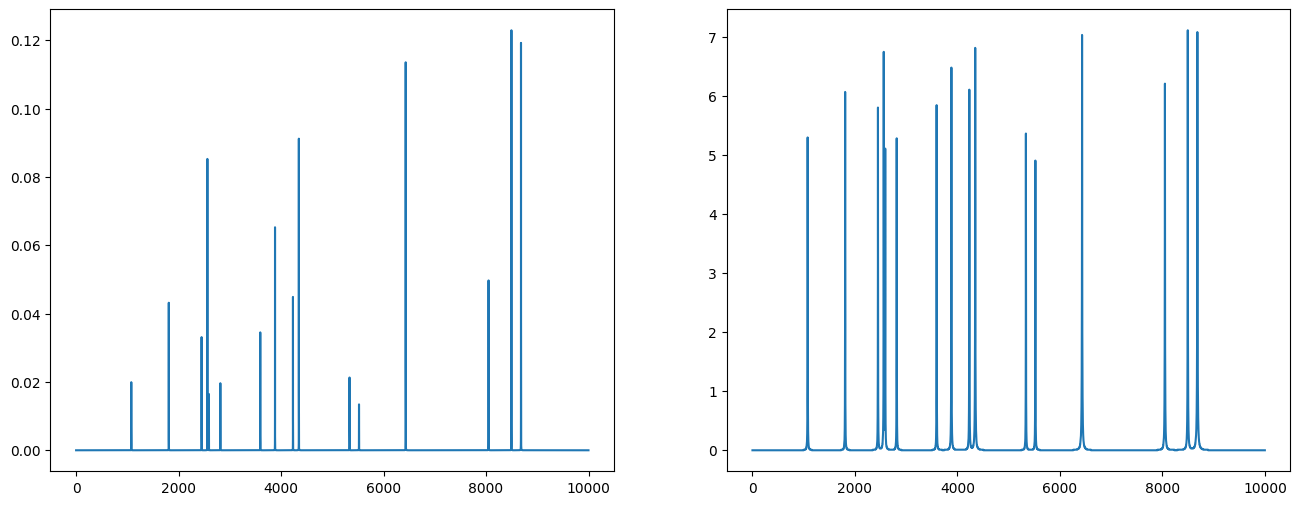

3449


In [31]:
idx = np.random.randint(len(train_data))
sample = train_data[idx]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(inverse_transform_data(sample))
axes[1].plot(sample)
plt.show()
print((sample != 0).sum())

In [ ]:
# Best Model
class ConvVAE(nn.Module):
    def __init__(self, input_dim, latent_dim, dropout=0.1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 8,  kernel_size=17, stride=4, padding=8),
            nn.GELU(),
            nn.Conv1d(8, 16, kernel_size=17, stride=4, padding=8),
            nn.GELU(),
            nn.Conv1d(16, 32, kernel_size=17, stride=4, padding=8),
            nn.GELU(),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_dim)
            enc_out = self.encoder(dummy)
            self.enc_shape = enc_out.shape[1:]  # (32, L')
            flat_dim = enc_out.numel()
        print(flat_dim)

        self.fc_mu     = nn.Linear(flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(flat_dim, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, flat_dim)
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(32, 16, kernel_size=17, stride=4, padding=8, output_padding=3),
            nn.GELU(),
            nn.ConvTranspose1d(16,  8, kernel_size=17, stride=4, padding=8, output_padding=3),
            nn.GELU(),
            nn.ConvTranspose1d( 8,  1, kernel_size=17, stride=4, padding=8, output_padding=3),
        )
        self.output_conv = nn.Conv1d(1, 1, kernel_size=7, padding=3)
        self.input_dim = input_dim

    def encode(self, x):
        x = x.unsqueeze(1)
        h = self.encoder(x)
        h = h.flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(mu) * (0.5 * logvar).exp()
        return mu

    def decode(self, z):
        h = F.gelu(self.fc_decode(z))                    # (B, flat_dim)
        h = h.view(z.size(0), *self.enc_shape)           # (B, 32, L')
        h = self.decoder(h)                              # (B, 1, 10048)
        h = h[..., :self.input_dim]
        h = self.output_conv(h)                          
        return h.squeeze(1)                              # (B, 10000)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = self.reparameterize(mu, logvar)
        x_out      = F.softplus(self.decode(z))
        return x_out, mu, logvar
    
def vae_loss(preds, targets, mu, logvar, beta=0.1):
    rec = F.mse_loss(preds, targets)
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return rec + beta * kl, rec, kl

In [125]:
class ResBlock1d(nn.Module):
    """Residual block at fixed resolution (no stride). Used between strided layers."""
    def __init__(self, channels, kernel_size=17, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=kernel_size, padding=kernel_size//2, groups=channels),  # depthwise
            nn.Conv1d(channels, channels, kernel_size=1),                                                      # pointwise
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(channels, channels, kernel_size=kernel_size, padding=kernel_size//2, groups=channels),
            nn.Conv1d(channels, channels, kernel_size=1),
        )
        self.norm = nn.GroupNorm(num_groups=min(8, channels), num_channels=channels)

    def forward(self, x):
        return F.gelu(self.norm(x + self.block(x)))


class DownBlock(nn.Module):
    """Strided conv to halve/quarter resolution + one residual refinement."""
    def __init__(self, in_ch, out_ch, stride=4, dropout=0.1):
        super().__init__()
        self.down = nn.Conv1d(in_ch, out_ch, kernel_size=17, stride=stride, padding=8)
        self.norm = nn.GroupNorm(num_groups=min(8, out_ch), num_channels=out_ch)
        self.res  = ResBlock1d(out_ch, dropout=dropout)

    def forward(self, x):
        return self.res(F.gelu(self.norm(self.down(x))))


class UpBlock(nn.Module):
    """Strided convtranspose to double/quadruple resolution + one residual refinement."""
    def __init__(self, in_ch, out_ch, stride=4, dropout=0.1):
        super().__init__()
        self.up   = nn.ConvTranspose1d(in_ch, out_ch, kernel_size=17, stride=stride,
                                        padding=8, output_padding=stride-1)
        self.norm = nn.GroupNorm(num_groups=min(8, out_ch), num_channels=out_ch)
        self.res  = ResBlock1d(out_ch, dropout=dropout)

    def forward(self, x):
        return self.res(F.gelu(self.norm(self.up(x))))


class ConvVAE(nn.Module):
    def __init__(self, input_dim, latent_dim, dropout=0.1):
        super().__init__()

        # --- Encoder ---
        self.enc_in = nn.Conv1d(1, 8, kernel_size=1)   # channel lift, no spatial change
        self.down1  = DownBlock( 8, 16, stride=4, dropout=dropout)
        self.down2  = DownBlock(16, 32, stride=4, dropout=dropout)
        self.down3  = DownBlock(32, 32, stride=4, dropout=dropout)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_dim)
            enc_out = self._encode_conv(dummy)
            self.enc_shape = enc_out.shape[1:]   # (32, ~157)
            flat_dim = enc_out.numel()
            print(f"flat_dim: {flat_dim}")

        self.fc_mu     = nn.Linear(flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(flat_dim, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, flat_dim)

        # --- Decoder (mirrors encoder) ---
        self.up1     = UpBlock(32, 32, stride=4, dropout=dropout)
        self.up2     = UpBlock(32, 16, stride=4, dropout=dropout)
        self.up3     = UpBlock(16,  8, stride=4, dropout=dropout)
        self.dec_out = nn.Conv1d(8, 1, kernel_size=7, padding=3)  # channel collapse + sharpening

        self.input_dim = input_dim

    def _encode_conv(self, x):
        x = F.gelu(self.enc_in(x))
        x = self.down1(x)
        x = self.down2(x)
        x = self.down3(x)
        return x

    def encode(self, x):
        h = self._encode_conv(x.unsqueeze(1)).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(mu) * (0.5 * logvar).exp()
        return mu

    def decode(self, z):
        h = F.gelu(self.fc_decode(z))
        h = h.view(z.size(0), *self.enc_shape)   # (B, 32, ~157)
        h = self.up1(h)
        h = self.up2(h)
        h = self.up3(h)
        h = h[..., :self.input_dim]              # trim to exact length
        return self.dec_out(h).squeeze(1)        # (B, 10000)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = self.reparameterize(mu, logvar)
        return F.softplus(self.decode(z)), mu, logvar


def vae_loss(preds, targets, mu, logvar, beta=0.1):
    rec = F.mse_loss(preds, targets)
    kl  = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return rec + beta * kl, rec, kl

In [126]:
device = 'cuda'
input_dim = data[0].shape[0]
latent_dim = 256
batch_size = 512
lr = 3e-4

model = ConvVAE(input_dim, latent_dim).to(device)
optimizer = AdamW(model.parameters(), lr=lr)

train_loader = DataLoader(train_data, batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size, shuffle=False)

epochs = 1000
beta = 0.01

for epoch in range(epochs):
    train_loss = 0
    val_loss = 0
    rec_loss = 0
    kl_loss = 0

    pbar = tqdm(train_loader)
    for x in pbar:
        x = x.to(device)
        x_pred, mu, logvar = model(x)
        loss, rec, kl = vae_loss(x_pred, x, mu, logvar, beta)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        pbar.set_postfix({"rec": f"{rec.item():.3f}", "kl": f"{kl.item():.3f}",  "tot": f"{loss.item():.3f}"})        
        train_loss += loss.item()
        rec_loss += rec.item()
        kl_loss += kl.item()

    model.eval()
    with torch.no_grad():
        for x in val_loader:
            x = x.to(device)
            x_pred, mu, logvar = model(x)
            loss, rec, kl = vae_loss(x_pred, x, mu, logvar, beta)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    rec_loss /= len(train_loader)
    kl_loss /= len(train_loader)
    print(f"Epoch: {epoch:03d} | total={train_loss:.4f} | rec={rec_loss:.4f} | kl={kl_loss:.4f} | val={val_loss:.4f}")

flat_dim: 5024


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1242/1242 [01:04<00:00, 19.21it/s, rec=0.034, kl=1.340, tot=0.048]


Epoch: 000 | total=0.1754 | rec=0.1664 | kl=0.9078 | val=0.0439


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1242/1242 [01:02<00:00, 19.88it/s, rec=0.018, kl=0.128, tot=0.020]


Epoch: 001 | total=0.0317 | rec=0.0288 | kl=0.2921 | val=0.0208


...

Epoch: 021 | total=0.0041 | rec=0.0040 | kl=0.0063 | val=0.0044


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1242/1242 [01:02<00:00, 19.87it/s, rec=0.004, kl=0.006, tot=0.004]


Epoch: 022 | total=0.0039 | rec=0.0039 | kl=0.0059 | val=0.0041


 14%|███████████████▎                                                                                                | 170/1242 [00:08<00:54, 19.70it/s, rec=0.004, kl=0.006, tot=0.004]


KeyboardInterrupt: 

In [ ]:
# get data for tests
def get_preds_targets_latents(model, loader, limit=50):
    model.eval()
    preds = []
    targets = []
    latents = []
    i = 0
    with torch.no_grad():
        for x in loader:
            x_pred, mu, logvar = model(x.to(device))
            preds.append(x_pred.cpu().numpy())
            targets.append(x.cpu().numpy())
            latents.append(mu.cpu().numpy())
            i+=1
            if i > limit:
                break
    return np.concatenate(preds, axis=0), np.concatenate(targets, axis=0), np.concatenate(latents, axis=0)

preds_train, targets_train, zs_train = get_preds_targets_latents(model, train_loader)
preds_val, targets_val, zs_val = get_preds_targets_latents(model, val_loader, limit=1e9)
preds_val_normal, targets_val_normal = inverse_transform_data(preds_val), inverse_transform_data(targets_val)

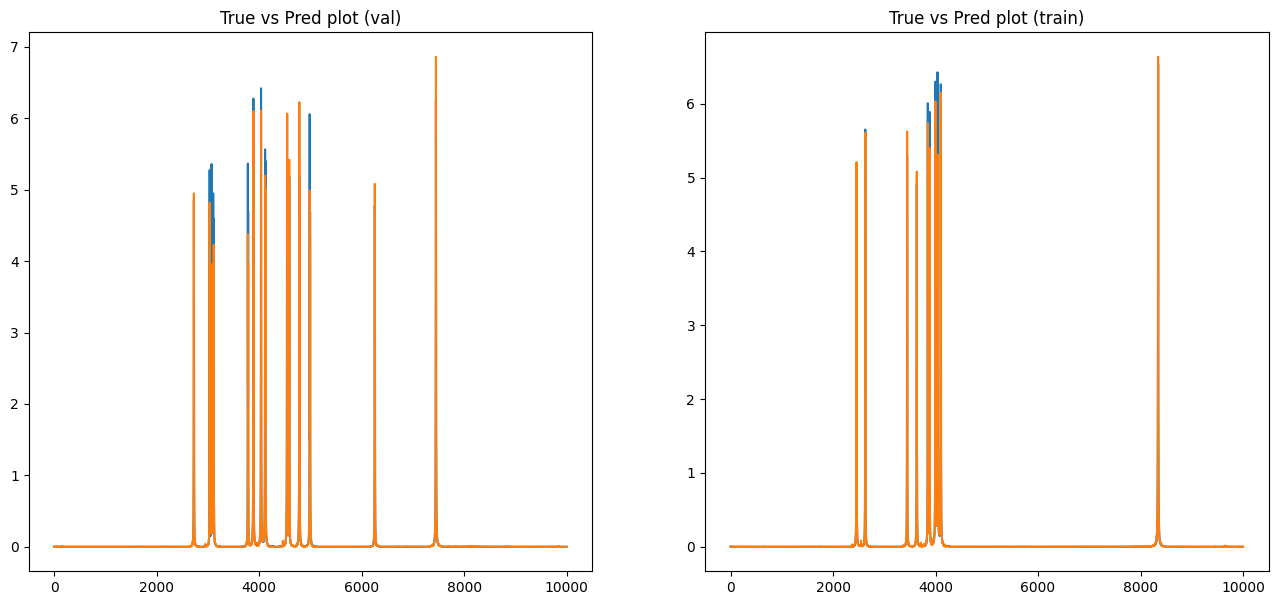

In [190]:
# reconstruction visualization
idx_val = np.random.randint(len(targets_val))
idx_train = np.random.randint(len(targets_train))

# x_val = inverse_transform_data(targets_val[idx_val])
# x_pred_val = inverse_transform_data(preds_val[idx_val])
# x_train = inverse_transform_data(targets_train[idx_train])
# x_pred_train = inverse_transform_data(preds_train[idx_train])
x_val = targets_val[idx_val]
x_pred_val = preds_val[idx_val]
x_train = targets_train[idx_train]
x_pred_train = preds_train[idx_train]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].plot(x_val, label='True')
axes[0].plot(x_pred_val, label="Pred")
axes[0].set_title('True vs Pred plot (val)')
axes[1].plot(x_train, label='True')
axes[1].plot(x_pred_train, label="Pred")
axes[1].set_title('True vs Pred plot (train)')
plt.show()

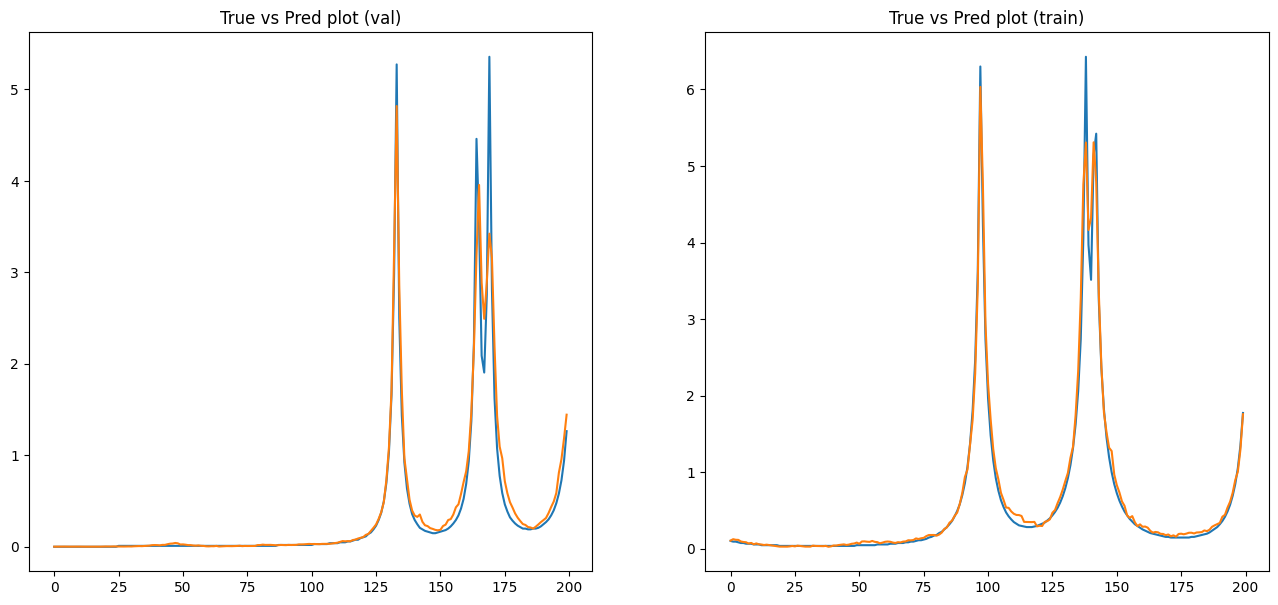

In [226]:
x_val = targets_val[idx_val]
x_pred_val = preds_val[idx_val]
x_train = targets_train[idx_train]
x_pred_train = preds_train[idx_train]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].plot(x_val[2900:3100], label='True')
axes[0].plot(x_pred_val[2900:3100], label="Pred")
axes[0].set_title('True vs Pred plot (val)')
axes[1].plot(x_train[3900:4100], label='True')
axes[1].plot(x_pred_train[3900:4100], label="Pred")
axes[1].set_title('True vs Pred plot (train)')
plt.show()

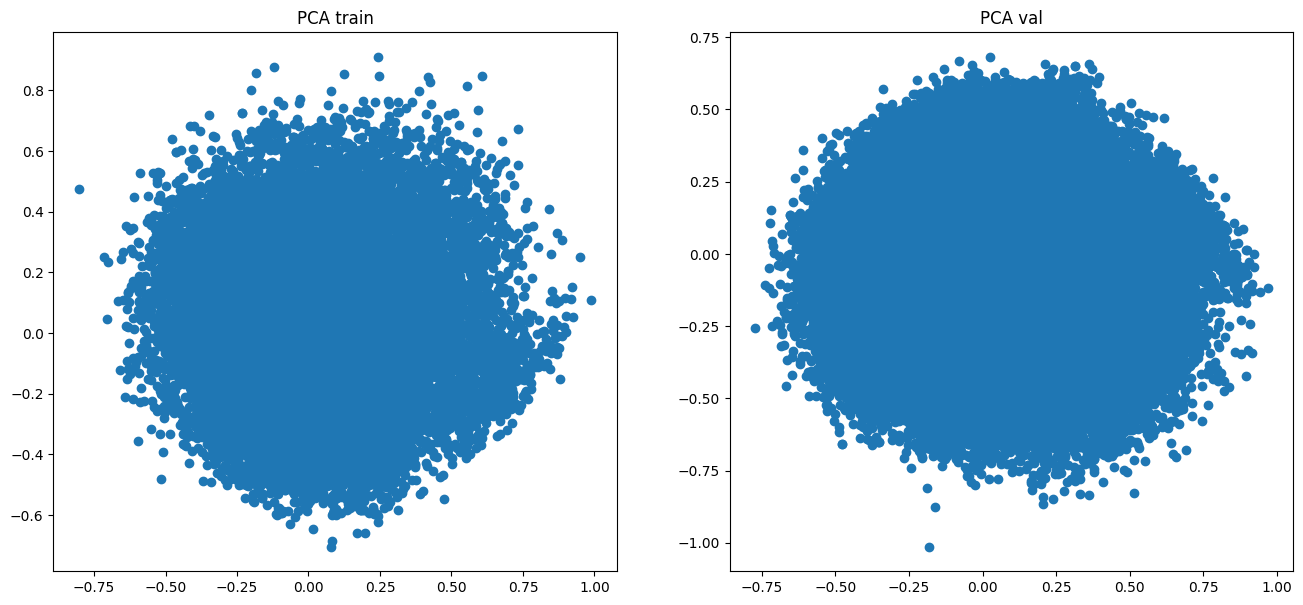

In [191]:
# PCA and r2
pca_z_train = PCA(n_components=2).fit_transform(zs_train)
pca_z_val = PCA(n_components=2).fit_transform(zs_val)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].scatter(pca_z_train[:, 0], pca_z_train[:, 1])
axes[0].set_title('PCA train')
axes[1].scatter(pca_z_val[:, 0], pca_z_val[:, 1])
axes[1].set_title('PCA val')
plt.show()

In [130]:
# saving
torch.save(model.state_dict(), '/home/andrze06/projects/Spectras-latent-space/trained_models/SimpleConvRes-l256.pt')

In [153]:
# accuracy:
thresh = 0.5

pred_mask = preds_val > thresh
true_mask = targets_val > thresh

tp = pred_mask & true_mask
fp = pred_mask & ~true_mask
fn = ~pred_mask & true_mask
tn = ~pred_mask & true_mask

tp = tp.sum()
fp = fp.sum()
fn = fn.sum()
tn = tn.sum()

accuracy = (tp + tn) / (tp + fp + fn + tn)
precision = tp / (tp + fp + 1e-8)
recall = tp / (tp + fn + 1e-8)
f1 = 2 * precision * recall / (precision + recall + 1e-8)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")

Accuracy:  0.9446
Precision: 0.9655
Recall:    0.9762
F1:        0.9708


In [184]:
threshold = 0.5
peak_tolerance = 3
tp = fp = fn = 0

for true_spec, pred_spec in tqdm(zip(targets_val, preds_val)):
    true_peaks, _ = find_peaks(true_spec, height=threshold)
    pred_peaks, _ = find_peaks(pred_spec, height=threshold)
    matched_true = set()

    for p in pred_peaks:
        found_match = False

        for i, t in enumerate(true_peaks):
            if i in matched_true:
                continue
            if abs(p - t) <= peak_tolerance:
                tp += 1
                matched_true.add(i)
                found_match = True
                break

        if not found_match:
            fp += 1

    fn += len(true_peaks) - len(matched_true)

precision = tp / (tp + fp + 1e-8)
recall = tp / (tp + fn + 1e-8)
f1 = 2 * precision * recall / (precision + recall + 1e-8)

print(f"Precision={precision:.4f}")
print(f"Recall={recall:.4f}")
print(f"F1={f1:.4f}")

79439it [00:07, 10283.23it/s]

Precision=0.8959
Recall=0.9488
F1=0.9216


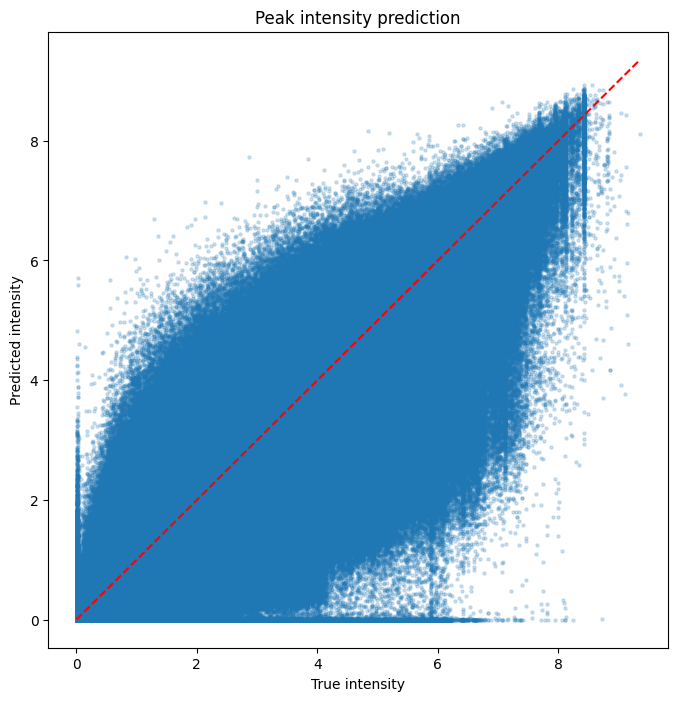

In [181]:
threshold = 0.0

mask = targets_val > threshold

true_peaks = targets_val[mask]
pred_peaks = preds_val[mask]

plt.figure(figsize=(8,8))
plt.scatter(true_peaks, pred_peaks, alpha=0.2, s=5)

m = max(true_peaks.max(), pred_peaks.max())
plt.plot([0, m], [0, m], 'r--')

plt.xlabel("True intensity")
plt.ylabel("Predicted intensity")
plt.title("Peak intensity prediction")
plt.show()

In [222]:
x = torch.tensor(np.zeros(shape=(1, 10000)), dtype=torch.float32, device=device)
x[:, 50] = 7
x[:, 9000] = 3
x_pred, mu, logvar = model(x)

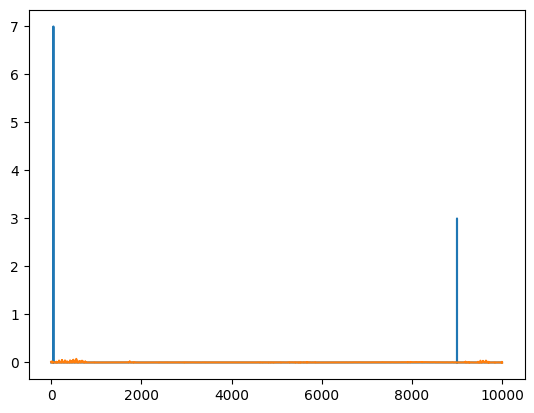

In [223]:
x_np = x.cpu().detach().numpy()
x_pred_np = x_pred.cpu().detach().numpy()

plt.plot(x_np[0])
plt.plot(x_pred_np[0])
plt.show()
